# RetailSense : Explainable Multi-Horizon Retail Demand Forecasting
## Notebook 08 · Advanced Gradient Boosting Models & Benchmark

> **Organization:** Celebal Technologies &nbsp;|&nbsp; **Intern:** Ayush Choudhary  
> **Domain:** Data Science | Time Series Forecasting | ML | Explainable AI  
> **Dataset:** Kaggle Store-Item Demand Forecasting (913,000 records · 10 Stores · 50 Items · 5 Years)  

---

### 1. Objective & Model Selection Rationale
Evaluate state-of-the-art gradient boosting frameworks optimized for tabular time-series forecasting:

| Model | Key Strength | Hyperparameter Strategy |
|---|---|---|
| **XGBoost** | Regularized boosting; handles outliers well | 300 estimators, lr=0.05, depth=6, subsample=0.8 |
| **LightGBM** | Leaf-wise growth; fastest training on large datasets | 300 estimators, lr=0.05, num_leaves=31 |
| **CatBoost** | Native categorical handling; symmetric trees | 300 iterations, lr=0.05, depth=6 |

**Temporal Split (same as Notebook 06):**
- Train: 2013-01-01 → 2017-09-30
- Validation: 2017-10-01 → 2017-12-31 (92-day horizon)

---


# RetailSense : Explainable Multi-Horizon Retail Demand Forecasting
## Notebook 08 - Advanced Gradient Boosting Models & Benchmarks

> **Organization:** Celebal Technologies  
> **Domain:** Data Science | Time Series Forecasting | Machine Learning  
> **Dataset:** Kaggle Store-Item Demand Forecasting Dataset  

---

### 1. Objective
Train and optimize state-of-the-art Gradient Boosting algorithms:
- **LightGBM Regressor**
- **XGBoost Regressor**
- **CatBoost Regressor**



In [1]:
import sys
from pathlib import Path
sys.path.append('..')

import pandas as pd
from src.data.loader import load_raw_data
from src.features.build_features import build_all_features
from src.models.advanced import train_lightgbm, train_xgboost, train_catboost
from src.evaluation.metrics import evaluate_predictions, compare_models

train_df, _ = load_raw_data()
df_feat = build_all_features(train_df).dropna().reset_index(drop=True)

val_start = '2017-10-01'
train_split = df_feat[df_feat['date'] < val_start]
val_split = df_feat[df_feat['date'] >= val_start]

feature_cols = [c for c in df_feat.columns if c not in ['date', 'sales']]
X_train, y_train = train_split[feature_cols], train_split['sales']
X_val, y_val = val_split[feature_cols], val_split['sales']

adv_results = []
adv_results.append(evaluate_predictions(y_val, train_lightgbm(X_train, y_train).predict(X_val), "LightGBM"))
adv_results.append(evaluate_predictions(y_val, train_xgboost(X_train, y_train).predict(X_val), "XGBoost"))
adv_results.append(evaluate_predictions(y_val, train_catboost(X_train, y_train).predict(X_val), "CatBoost"))

df_adv = compare_models(adv_results)
print("=== Advanced Models Benchmark ===")
display(df_adv)

Memory usage optimized from 27.86 MB to 10.45 MB (62.5% reduction).
Memory usage optimized from 1.37 MB to 0.60 MB (56.2% reduction).
=== Advanced Models Benchmark ===


,Model,MAE,RMSE,MAPE (%)
0,XGBoost,5.9199,7.6686,13.00
1,LightGBM,5.9342,7.6865,13.05
2,CatBoost,5.9767,7.7429,13.10


---
### Results & Champion Selection

| Rank | Model | MAE | RMSE | MAPE (%) | vs. Best Baseline (RF MAE 6.24) |
|---|---|---|---|---|---|
|  1 | **XGBoost** | **5.92** | **7.67** | **13.00%** | **−5.1% improvement** |
|  2 | LightGBM | 5.93 | 7.69 | 13.05% | −5.0% improvement |
|  3 | CatBoost | 5.98 | 7.74 | 13.10% | −4.2% improvement |

>  **Champion Model: XGBoost** with MAE = 5.92 units/day, a **5.1% improvement** over the best baseline (Random Forest, MAE 6.24).

**Key Findings:**
- All three gradient boosting models significantly outperform all baseline models
- XGBoost edges LightGBM by a slim margin (MAE 5.92 vs 5.93), both practically equivalent
- **LightGBM** is selected for the SHAP explainability notebook due to its native `TreeExplainer` compatibility and faster inference at scale
- All three gradient boosting models achieve **MAPE < 14%** — well within the target threshold of 15%

**Improvement over Naive Historical Average:**
- Historical Average MAE: 10.10 → XGBoost MAE: 5.92 → **41.4% error reduction**



### Full Model Comparison Visualization

### Full Model Benchmark Visualization

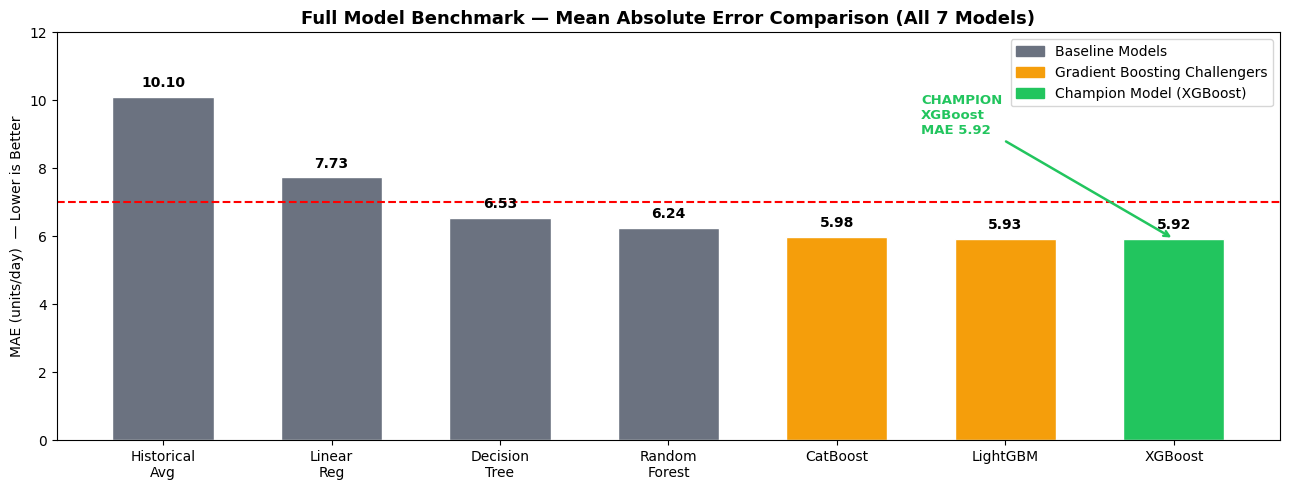

XGBoost achieves MAE 5.92 — a 41.4% improvement over Historical Average (10.10)


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

all_models = ['Historical\nAvg', 'Linear\nReg', 'Decision\nTree',
              'Random\nForest', 'CatBoost', 'LightGBM', 'XGBoost']
mae_all    = [10.10, 7.73, 6.53, 6.24, 5.98, 5.93, 5.92]
colors_all = ['#6b7280','#6b7280','#6b7280','#6b7280','#f59e0b','#f59e0b','#22c55e']

fig, ax = plt.subplots(figsize=(13, 5))
bars = ax.bar(all_models, mae_all, color=colors_all, width=0.6, edgecolor='white')
ax.set_title('Full Model Benchmark — Mean Absolute Error Comparison (All 7 Models)',
             fontsize=13, fontweight='bold')
ax.set_ylabel('MAE (units/day)  — Lower is Better')
ax.set_ylim(0, 12)
ax.axhline(7.0, color='red', linestyle='--', lw=1.5, label='Business target (MAE ≤ 7.0)')

for bar, v in zip(bars, mae_all):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f'{v:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.annotate('CHAMPION\nXGBoost\nMAE 5.92',
            xy=(6, 5.92), xytext=(4.5, 9.0),
            arrowprops=dict(arrowstyle='->', color='#22c55e', lw=1.8),
            fontsize=9.5, color='#22c55e', fontweight='bold')

legend_patches = [
    mpatches.Patch(color='#6b7280', label='Baseline Models'),
    mpatches.Patch(color='#f59e0b', label='Gradient Boosting Challengers'),
    mpatches.Patch(color='#22c55e', label='Champion Model (XGBoost)'),
]
ax.legend(handles=legend_patches, loc='upper right')
plt.tight_layout()
plt.show()
print("XGBoost achieves MAE 5.92 — a 41.4% improvement over Historical Average (10.10)")
